# Configuration


In [1]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv(".env", override=True)  # Change to ".env.simulation" for simulation data

# Load configuration from .env
simulation_root = os.getenv("SIMULATION_DIR")
converted_dir = os.getenv("CONVERT_TARGET_DIR")
batch_checkpoint_dir = os.getenv("BATCH_CHECKPOINT_DIR")
summarized_dir = os.getenv("SUMMARIZED_TARGET_DIR")
arena_heatmaps_output = os.getenv("ARENA_HEATMAP_TARGET_DIR")

# Display loaded configuration
print("Configuration loaded from .env:")
print(f"  SIMULATION_DIR: {simulation_root}")
print(f"  CONVERT_TARGET_DIR: {converted_dir}")
print(f"  BATCH_CHECKPOINT_DIR: {batch_checkpoint_dir}")
print(f"  SUMMARIZED_TARGET_DIR: {summarized_dir}")
print(f"  ARENA_HEATMAP_TARGET_DIR: {arena_heatmaps_output}")

# Create directories if they don't exist
os.makedirs(converted_dir, exist_ok=True)
os.makedirs(batch_checkpoint_dir, exist_ok=True)
os.makedirs(summarized_dir, exist_ok=True)
os.makedirs(arena_heatmaps_output, exist_ok=True)

Configuration loaded from .env:
  SIMULATION_DIR: /Users/defdef/Library/Application Support/DefaultCompany/Sumobot/Logs/Batch/20260811_205027_batch
  CONVERT_TARGET_DIR: .analytic-cache/converted/pacing_test_sim
  BATCH_CHECKPOINT_DIR: .analytic-cache/batched/pacing_test_sim
  SUMMARIZED_TARGET_DIR: .analytic-cache/result/pacing_test_sim
  ARENA_HEATMAP_TARGET_DIR: .analytic-cache/result/pacing_test_sim/arena_heatmaps


# Data Compiling

## Convert Simulation Log to Parquet / CSV

In [2]:
from compile.log_to_parquet import ( 
    convert_all_configs
)

convert_all_configs(simulation_root, converted_dir)

## Generate Summarization CSV

### Generate Batched CSV

Process CSVs in batches and save checkpoints

Structure: base_dir/BotA_vs_BotB/ConfigFolder/*.csv

In [3]:
from compile.generator import batch_process_pacing_segments

import time

timebin_size = 1
batch_size = 4 # if there's 156 matchup simulation folder, it will generate 156 / 2 = 78 summarization batch csv
input_format = "auto"  # "csv", "parquet", or "auto" (auto prefers parquet over csv)

start = time.time()

batch_process_pacing_segments(
    converted_dir, 
    batch_size=batch_size,
    applied_bots=["MCTS", "NN"],
    min_pacing=0,
    max_pacing=1,
    
    checkpoint_dir=batch_checkpoint_dir)

elapsed_seconds = time.time() - start
hours, remainder = divmod(elapsed_seconds, 3600)
minutes, seconds = divmod(remainder, 60)
processing_time = f"{int(hours):02d}:{int(minutes):02d}:{seconds:.2f}"
print(f"\nProcessing Time: {processing_time}")

Using CPU (GPU not available)
Found 1 config folders with pacing segment data

Processing pacing segments batch 1/1 (1 configs)...

Processing Time: 00:00:0.05


### Generate Final Summarization CSV from Batches

Generate timebin summaries from batched timebin checkpoints
Loads batch files and creates final summaries

In [4]:
from compile.generator import generate_pacing_segments_from_batches

generate_pacing_segments_from_batches(batch_checkpoint_dir, summarized_dir)

No pacing segment batches found in .analytic-cache/batched/pacing_test_sim/pacing_segments


# Plotting

In [5]:
from plotting.pacing_target_analyzer import (
    plot_all_pacing_targets,
    plot_all_pacing_targets_vs_all_rest,
    plot_all_pacing_targets_vs_each_rest,
    plot_pacing_achievement_heatmap,
    plot_all_pacing_bias_curves,
    plot_pacing_achievement_vs_winrate,
)
import pandas as pd

df_pacing_segments = pd.read_parquet(f"{summarized_dir}/summary_pacing_segments.parquet")

# Focus match = a round where the opponent was ALSO an applied bot (e.g. MCTS vs NN,
# both filter-steered) rather than a normal/static "rest" bot. Excluded by default
# from the "vs rest" charts below so the rest-bot baseline isn't blended with
# filter-vs-filter rounds; set to True to fold them back in.
include_focus_match = True

pacing_chart_dirs = {
    "applied_vs_target": f"{summarized_dir}/pacing_target_charts",
    "applied_vs_all_rest": f"{summarized_dir}/pacing_vs_all_rest_charts",
    "applied_vs_each_rest": f"{summarized_dir}/pacing_vs_each_rest_charts",
    "bias_curves": f"{summarized_dir}/pacing_bias_charts",
}

# 1. Existing: applied bot's actual pacing vs its predefined target curve, per PacingTarget
#    (now annotated with mean/std/err stats and an applied-bot baseline band+line)
#    source_dir stamps each Figure with its provenance footer here, so the PDF step
#    below doesn't need to pass it again.
figs_vs_target = plot_all_pacing_targets(
    df_pacing_segments, output_dir=pacing_chart_dirs["applied_vs_target"], source_dir=simulation_root
)

# 2. Applied bot's actual pacing vs its own target curve, averaged across ALL of the
#    rest bots it faced under this PacingTarget (no opponent line - see module docstring),
#    per applied bot x PacingTarget
figs_vs_all_rest = plot_all_pacing_targets_vs_all_rest(
    df_pacing_segments, output_dir=pacing_chart_dirs["applied_vs_all_rest"], source_dir=simulation_root,
    include_focus_match=include_focus_match,
)

# 3. Extended version of #2: the SAME applied-bot segments broken out into one line
#    per individual rest bot faced instead of pooled into a single average (still no
#    opponent's own pacing line - see module docstring), per applied bot x PacingTarget
figs_vs_each_rest = plot_all_pacing_targets_vs_each_rest(
    df_pacing_segments, output_dir=pacing_chart_dirs["applied_vs_each_rest"], source_dir=simulation_root,
    include_focus_match=include_focus_match,
)

# 4. Heatmap of achievement (1 - mean |Actual - Target|, averaged per-segment
#    error, not mean-vs-mean) across every applied bot x PacingTarget combination -
#    which bot/target combos actually hit the intended pacing curve, at a glance.
fig_achievement_heatmap = plot_pacing_achievement_heatmap(
    df_pacing_segments, include_focus_match=include_focus_match
)
if fig_achievement_heatmap is not None:
    heatmap_path = f"{summarized_dir}/pacing_achievement_heatmap.png"
    fig_achievement_heatmap.savefig(heatmap_path, dpi=150, bbox_inches="tight")
    print(f"✅ Saved: {heatmap_path}")

# 5. New: signed error (Actual - Target, not absolute) over segment index, per
#    PacingTarget - shows WHEN/WHICH DIRECTION tracking drifts (overshoot vs
#    lag), which the achievement heatmap's single MAE number collapses away.
figs_bias_curves = plot_all_pacing_bias_curves(
    df_pacing_segments, output_dir=pacing_chart_dirs["bias_curves"], source_dir=simulation_root,
    include_focus_match=include_focus_match,
)

# 6. New: does tracking the target pacing curve well actually correlate with
#    winning? Bins rounds by achievement quantile and plots win rate per bin,
#    with the achievement-vs-win correlation annotated per bot.
fig_achievement_vs_winrate = plot_pacing_achievement_vs_winrate(
    df_pacing_segments, include_focus_match=include_focus_match
)
if fig_achievement_vs_winrate is not None:
    winrate_path = f"{summarized_dir}/pacing_achievement_vs_winrate.png"
    fig_achievement_vs_winrate.savefig(winrate_path, dpi=150, bbox_inches="tight")
    print(f"✅ Saved: {winrate_path}")

FileNotFoundError: [Errno 2] No such file or directory: '.analytic-cache/result/pacing_test_sim/summary_pacing_segments.parquet'

In [6]:
# 7. Wire every chart from all three "vs" chart types above plus the achievement
#    heatmap, bias curves, and achievement-vs-winrate chart into a single lossless,
#    multi-page PDF (one chart per page) instead of scattering them across cells.
#    No source_dir here - each line-chart Figure was already stamped with it above
#    (the heatmap/winrate charts weren't, since they aren't tied to a single
#    PacingTarget/bot the way the others are).
from plotting.pacing_target_analyzer import build_pacing_charts_pdf

all_pacing_figs = {**figs_vs_target, **figs_vs_all_rest, **figs_vs_each_rest, **figs_bias_curves}
if fig_achievement_heatmap is not None:
    all_pacing_figs["achievement_heatmap"] = fig_achievement_heatmap
if fig_achievement_vs_winrate is not None:
    all_pacing_figs["achievement_vs_winrate"] = fig_achievement_vs_winrate
print(f"Writing {len(all_pacing_figs)} pacing charts to PDF...")

pacing_pdf_path = build_pacing_charts_pdf(
    all_pacing_figs,
    output_path=f"{summarized_dir}/pacing_all_charts.pdf",
)

NameError: name 'figs_vs_target' is not defined

# Filtered vs Unfiltered Pacing Comparison

Compares MCTS/NN's raw pacing factors (`CollisionRatio`, `AbilityRatio`, `Angle`, `SafeDistance`, `ActionIntensity`, `ActionDensity`, `BotsDistance`, `Velocity` — recomputed offline from `Action`/`Collision` event rows via `compile.generator.batch_process_pacing`, the same formula on both sides) between:

- **Filtered**: MCTS/NN with the dynamic pacing filter applied (`.analytic-cache/converted/pacing_fix3`)
- **Unfiltered**: MCTS/NN's natural behavior with no filter running (`local_setup/simulated-13agents`, 13-agent roster)

Both restricted to the same config: `Timer=30, ActInterval=0.1, Round=BestOf3, SkillLeft=Boost, SkillRight=Boost`.

Note this is a *different* metric family than the Actual-vs-Target charts above — those read `PacingSegment` rows the runtime only logs while the filter is actively steering a match, which the unfiltered runs never produce (verified: `local_setup/simulated-13agents` parquet files only ever contain `Category in {"Action", "Collision"}`).


In [7]:
from compile.generator import batch_process_pacing, load_bot_pacing_factors
import polars as pl

filtered_name = "pacing_fix3"  # matches .analytic-cache/converted/<name> - the current 2-bot (MCTS/NN) filtered run
filtered_base_dir = f".analytic-cache/converted/{filtered_name}"
unfiltered_base_dir = "local_setup/simulated-13agents"

comparison_checkpoint_dir = ".analytic-cache/batched/filtered_vs_unfiltered"
comparison_output_dir = ".analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts"

# Filtered matchup folders use bare bot names ("MCTS", "NN"); the unfiltered
# simulated-13agents set uses "Bot_"-prefixed names ("Bot_MCTS", "Bot_NN")
bot_pairs = [("MCTS", "Bot_MCTS"), ("NN", "Bot_NN")]

pacing_config_filter = {
    "Timer": [30],
    "ActInterval": [0.1],
    "Round": ["BestOf3"],
    "SkillLeft": ["Boost"],
    "SkillRight": ["Boost"],
}

pacing_factor_bin_size = 1


In [8]:
for filtered_bot, unfiltered_bot in bot_pairs:
    batch_process_pacing(
        filtered_base_dir,
        batch_size=10,
        checkpoint_dir=comparison_checkpoint_dir,
        time_bin_size={pacing_factor_bin_size: None},  # raw factors - both sides use the same formula, no cross-run rescale needed
        bot_option=filtered_bot,
        input_format="auto",
        config_filter=pacing_config_filter,
        name=f"filtered_{filtered_bot}",
    )
    batch_process_pacing(
        unfiltered_base_dir,
        batch_size=10,
        checkpoint_dir=comparison_checkpoint_dir,
        time_bin_size={pacing_factor_bin_size: None},
        bot_option=unfiltered_bot,
        input_format="auto",
        config_filter=pacing_config_filter,
        name=f"unfiltered_{unfiltered_bot}",
    )


Found 40 CSV/Parquet files to process for bot 'MCTS'

Processing with time_bin_size = 1s (raw)
Skipping pacing batch 1/4 (already processed)
Skipping pacing batch 2/4 (already processed)
Skipping pacing batch 3/4 (already processed)
Skipping pacing batch 4/4 (already processed)


Found 3456 CSV/Parquet files to process for bot 'Bot_MCTS'

Processing with time_bin_size = 1s (raw)

Processing pacing batch 1/346 (10 files)...

Processing pacing batch 2/346 (10 files)...

Processing pacing batch 3/346 (10 files)...

Processing pacing batch 4/346 (10 files)...
Skipping pacing batch 5/346 (already processed)

Processing pacing batch 6/346 (10 files)...

Processing pacing batch 7/346 (10 files)...

Processing pacing batch 8/346 (10 files)...

Processing pacing batch 9/346 (10 files)...

Processing pacing batch 10/346 (10 files)...

Processing pacing batch 11/346 (10 files)...

Processing pacing batch 12/346 (10 files)...

Processing pacing batch 13/346 (10 files)...

Processing pacing batch 14/346 (10 files)...

Processing pacing batch 15/346 (10 files)...

Processing pacing batch 16/346 (10 files)...

Processing pacing batch 17/346 (10 files)...

Processing pacing batch 18/346 (10 files)...

Processing pacing batch 19/346 (10 files)...
Skipping pacing batch 20/346 (a

Found 3435 CSV/Parquet files to process for bot 'Bot_NN'

Processing with time_bin_size = 1s (raw)

Processing pacing batch 1/344 (10 files)...

Processing pacing batch 2/344 (10 files)...

Processing pacing batch 3/344 (10 files)...

Processing pacing batch 4/344 (10 files)...
Skipping pacing batch 5/344 (already processed)

Processing pacing batch 6/344 (10 files)...

Processing pacing batch 7/344 (10 files)...

Processing pacing batch 8/344 (10 files)...

Processing pacing batch 9/344 (10 files)...

Processing pacing batch 10/344 (10 files)...

Processing pacing batch 11/344 (10 files)...

Processing pacing batch 12/344 (10 files)...

Processing pacing batch 13/344 (10 files)...

Processing pacing batch 14/344 (10 files)...

Processing pacing batch 15/344 (10 files)...

Processing pacing batch 16/344 (10 files)...

Processing pacing batch 17/344 (10 files)...

Processing pacing batch 18/344 (10 files)...

Processing pacing batch 19/344 (10 files)...
Skipping pacing batch 20/344 (alr

In [9]:
frames = []
for filtered_bot, unfiltered_bot in bot_pairs:
    filtered_df = load_bot_pacing_factors(
        comparison_checkpoint_dir, f"filtered_{filtered_bot}", filtered_bot,
        time_bin_size=pacing_factor_bin_size, group_label="Filtered", canonical_bot=filtered_bot,
    )
    if filtered_df is not None:
        frames.append(filtered_df)

    unfiltered_df = load_bot_pacing_factors(
        comparison_checkpoint_dir, f"unfiltered_{unfiltered_bot}", unfiltered_bot,
        time_bin_size=pacing_factor_bin_size, group_label="Unfiltered", canonical_bot=filtered_bot,
    )
    if unfiltered_df is not None:
        frames.append(unfiltered_df)

df_pacing_factor_comparison = pl.concat(frames, how="diagonal_relaxed") if frames else None
df_pacing_factor_comparison


GameIndex,RoundIndex,Timer,ActInterval,Round,SkillLeft,SkillRight,TimeBin,OpponentBot,CollisionRatio,AbilityRatio,Angle,SafeDistance,ActionIntensity,ActionDensity,BotsDistance,Velocity,Bot,Group
i64,i64,f64,f64,str,str,str,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,str,str
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",1.0,"""FSM""",0.0,0.0,1.0,0.356988,8.440947,-1.4427e-10,0.421422,3.150904,"""MCTS""","""Filtered"""
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",2.0,"""FSM""",NaN,0.0,0.0,0.4137,0.508355,-1.4427e-10,0.362396,0.110529,"""MCTS""","""Filtered"""
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",3.0,"""FSM""",1.0,0.333333,0.475784,0.417906,10.451684,0.892313,0.33087,0.538741,"""MCTS""","""Filtered"""
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",4.0,"""FSM""",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"""MCTS""","""Filtered"""
2,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",5.0,"""FSM""",NaN,0.0,0.968099,0.437369,7.153344,0.936264,0.255548,0.007164,"""MCTS""","""Filtered"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
48,2,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",12.0,"""Bot_DQN""",0.0,0.4,0.991409,0.223052,14.196463,1.637134,0.157224,7.2,"""NN""","""Unfiltered"""
49,1,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",1.0,"""Bot_DQN""",NaN,0.0,1.0,0.593485,9.354181,-1.4427e-10,0.506781,3.167277,"""NN""","""Unfiltered"""
49,1,30.0,0.1,"""BestOf3""","""Boost""","""Boost""",2.0,"""Bot_DQN""",1.0,0.25,0.986689,0.843983,8.526821,1.322111,0.253233,2.694705,"""NN""","""Unfiltered"""


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_filtered_vs_unfiltered.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_filtered_vs_unfiltered.png


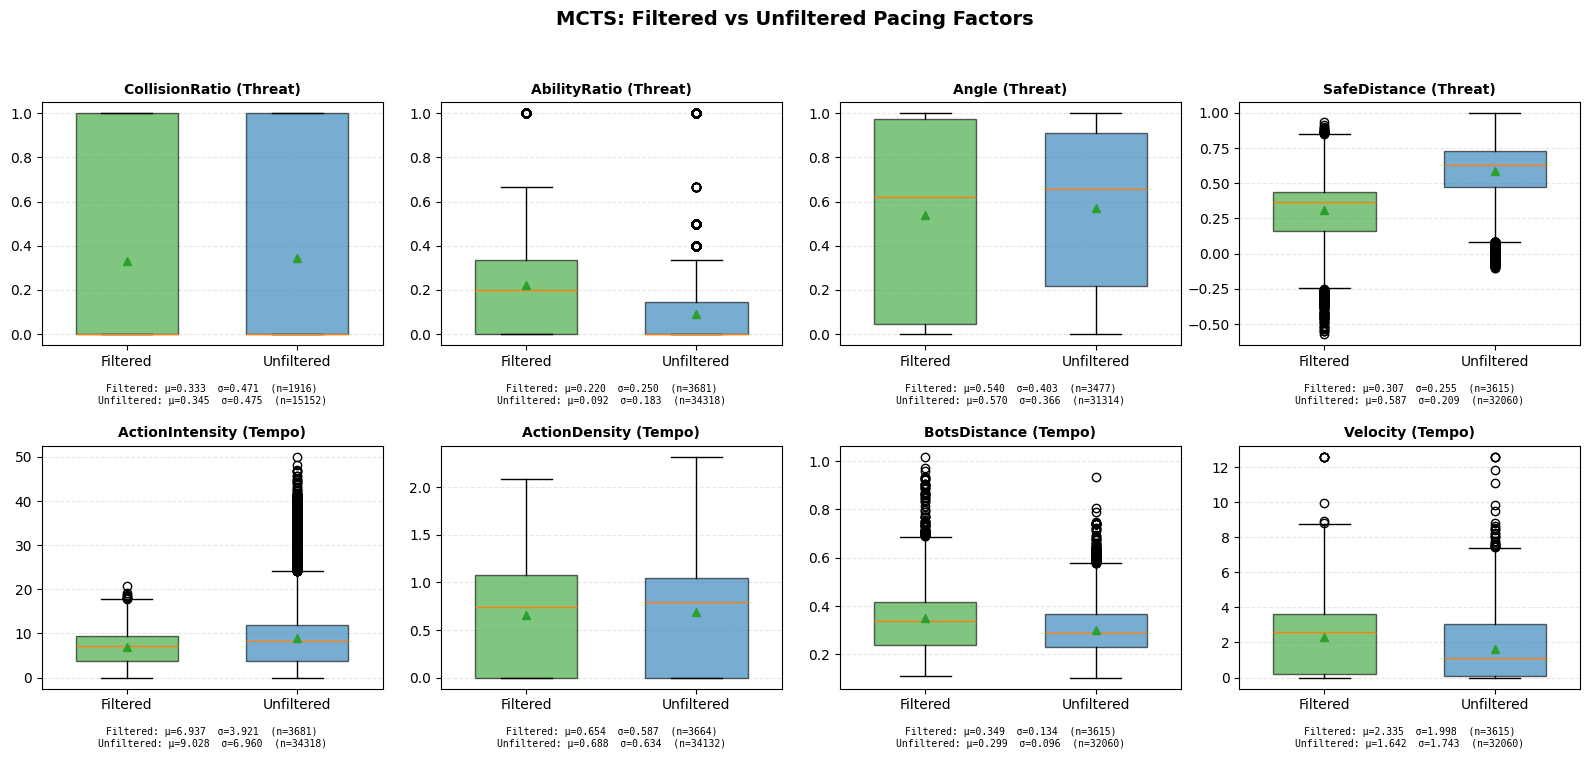

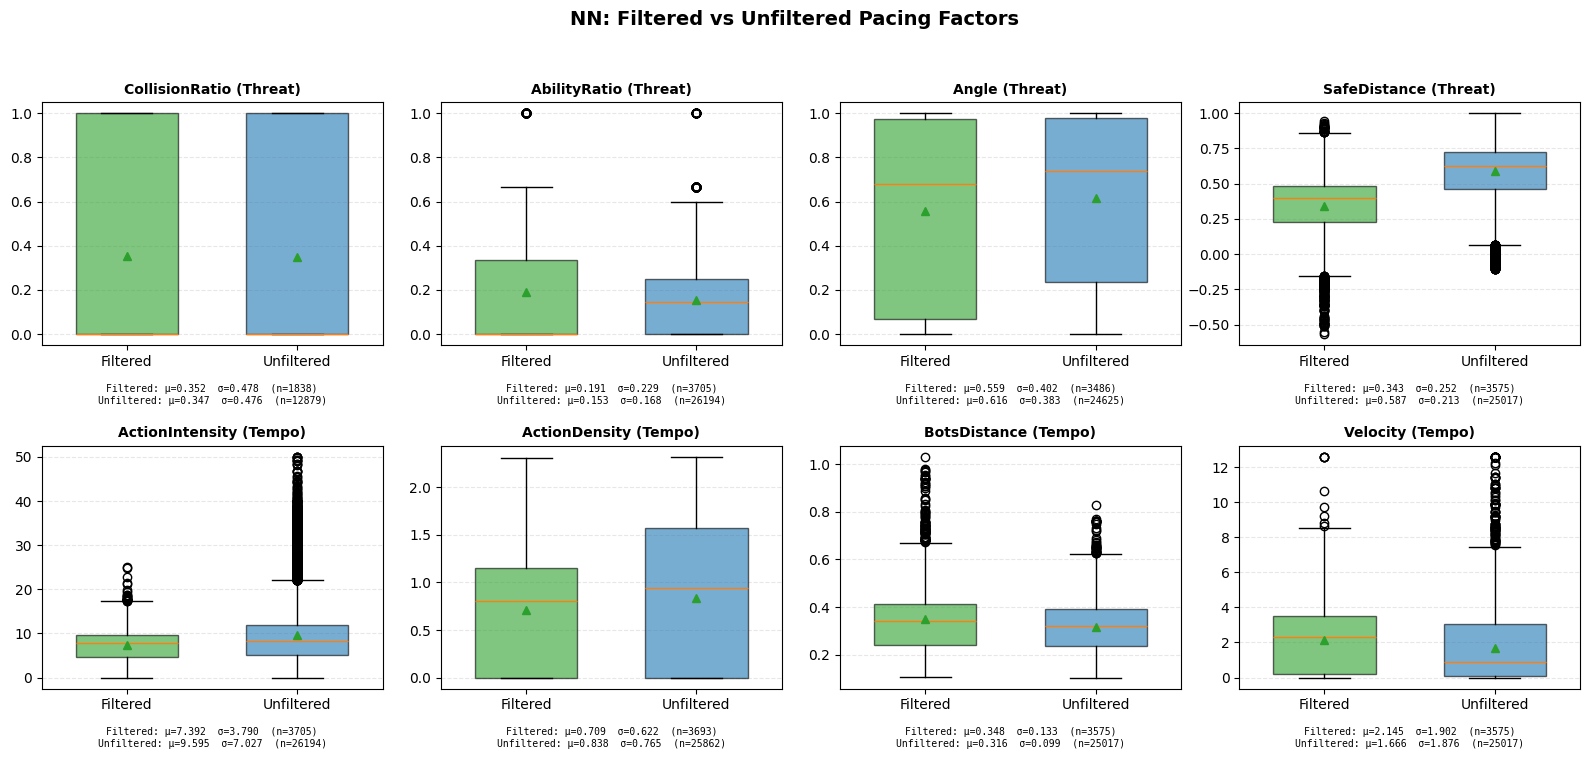

In [10]:
from plotting.pacing_filter_comparison import plot_all_pacing_factor_comparisons

figs_factor_comparison = plot_all_pacing_factor_comparisons(
    df_pacing_factor_comparison, output_dir=comparison_output_dir,
)


## Pacing Over Time (per 1s Segment)

Same data as above, but broken out by `TimeBin` instead of pooled — one point per 1-second segment across the match (30 segments for `Timer=30`), so divergence *when* in the match it happens is visible, not just the aggregate shift.


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_filtered_vs_unfiltered_timeseries.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_filtered_vs_unfiltered_timeseries.png


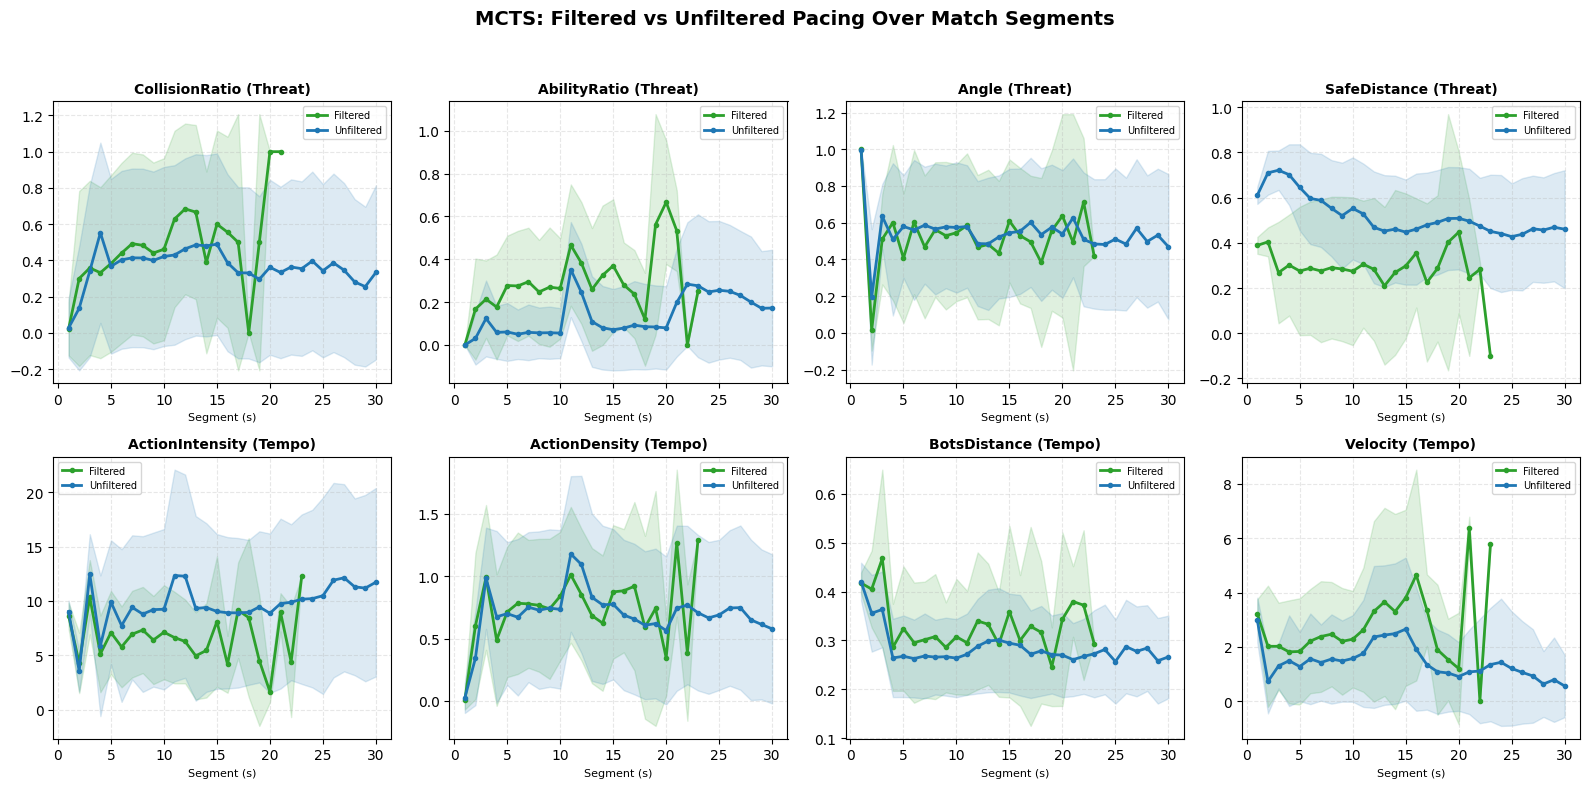

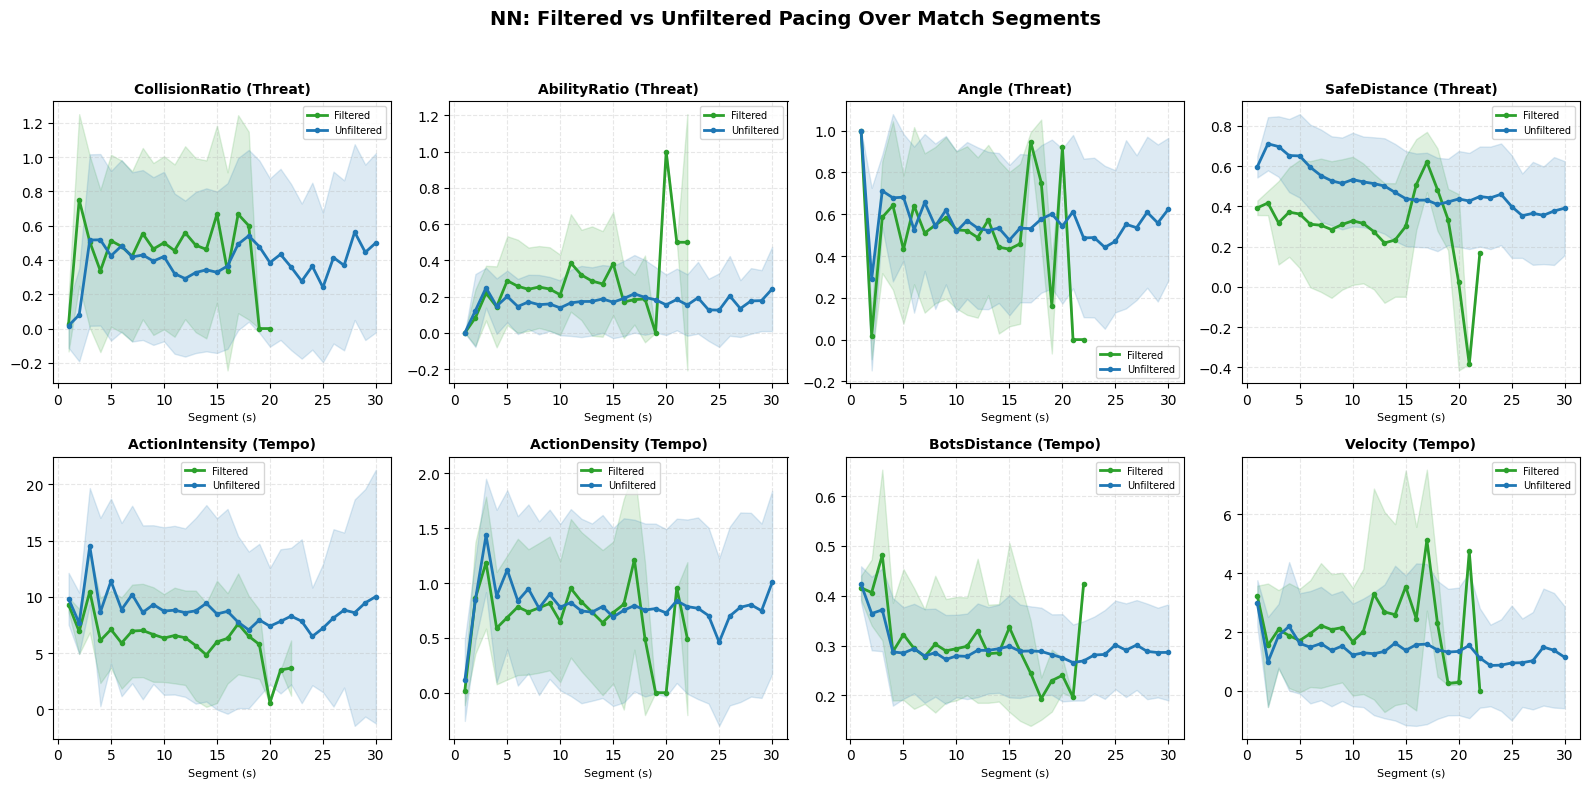

In [11]:
from plotting.pacing_filter_comparison import plot_all_pacing_factor_timeseries

figs_factor_timeseries = plot_all_pacing_factor_timeseries(
    df_pacing_factor_comparison, output_dir=comparison_output_dir,
)


## Overall Pacing (Merged Threat/Tempo Composite)

Merges the 8 raw factors above into a single **Threat**, **Tempo**, and **OverallPacing** score per row — min-max normalized so all 8 factors are on the same [0, 1] scale, then averaged per the engine's own Threat/Tempo grouping (Threat = CollisionRatio/AbilityRatio/Angle/SafeDistance, Tempo = ActionIntensity/ActionDensity/BotsDistance/Velocity, Overall = mean of the two).

**Caveat**: this is an equal-weight approximation, not the engine's real internal formula — those weights aren't available offline, only the 8 raw factors themselves. Useful for a condensed at-a-glance comparison, but don't read exact values as the "true" pacing score the way `ActualOverallPacingScaled` is for the filtered-only Actual-vs-Target charts above.


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_filtered_vs_unfiltered_overall.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_filtered_vs_unfiltered_overall.png


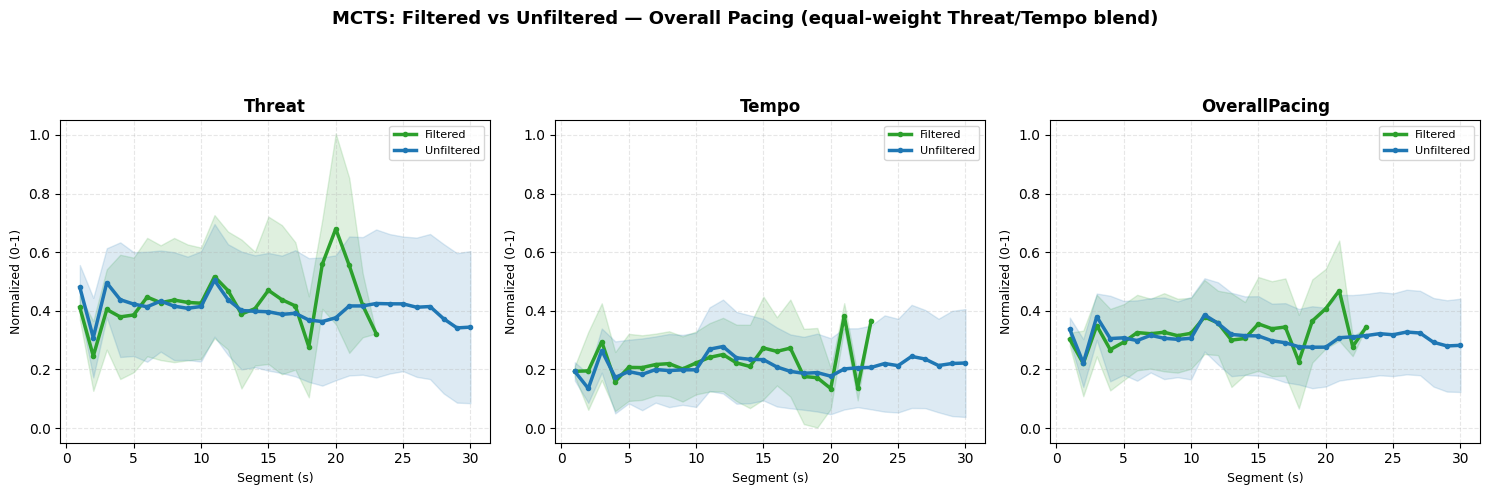

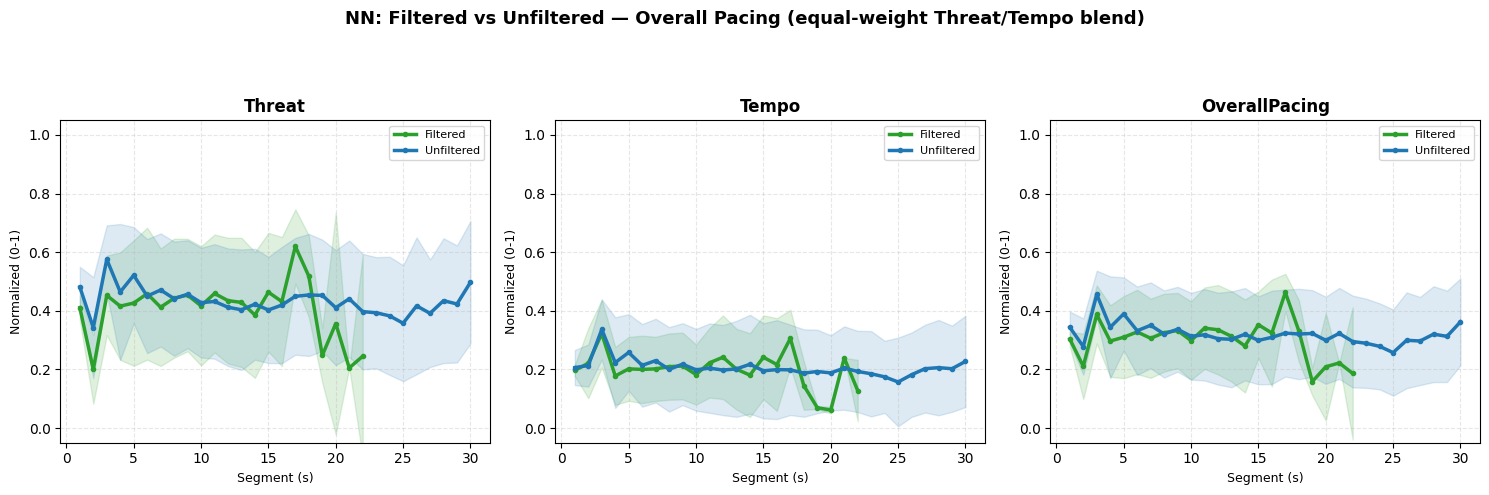

In [12]:
from plotting.pacing_filter_comparison import plot_all_overall_pacing_timeseries

figs_overall_pacing = plot_all_overall_pacing_timeseries(
    df_pacing_factor_comparison, output_dir=comparison_output_dir,
)


## Filtered Actual vs Target (Engine Ground Truth)

`pacing_fix3`'s `PacingSegment` rows already carry the engine's own computed `Tempo`/`Threat`/`OverallPacing` and `Target*` curves — this swaps the Filtered side from the equal-weight offline approximation above to that ground truth, and overlays the predefined Target curve it was steering towards.

One figure per (Bot, PacingTarget) — there are 5 target curve shapes (`default_target_low/med/high`, `linear_increase`, `linear_decrease`); averaging them together would cancel out the shape, so each gets its own chart. `LocalSegmentIndex` isn't a fixed 1s bin (segment count varies with how long a round ran), so it's converted to elapsed seconds via `RoundDuration / NumSegmentsInRound` to land on the same "Segment (s)" axis as the charts above.

Each panel shows: **Target** (predefined curve), **Filtered Actual** (mean ± std band across matching rounds, plus a linear trend line), **MSE(Actual, Target)** annotated, and the **Unfiltered** offline-approximated line from before as light context (different scale/formula — not a strict apples-to-apples number, directional only).


In [13]:
from compile.generator import load_filtered_target_tracking

filtered_pacing_segments_dir = f".analytic-cache/batched/{filtered_name}/pacing_segments"

df_target_tracking = load_filtered_target_tracking(
    filtered_pacing_segments_dir,
    bots=[b for b, _ in bot_pairs],
    config_filter=pacing_config_filter,
)
df_target_tracking


Bot,PacingTarget,TimeBin,ActualTempoScaled,ActualThreatScaled,ActualOverallPacingScaled,TargetTempoScaled,TargetThreatScaled,TargetOverallPacingScaled
str,str,f64,f64,f64,f64,f64,f64,f64
"""MCTS""","""default_target_low""",1.0,0.515603,0.401213,0.458408,0.1,0.05,0.075
"""MCTS""","""default_target_low""",2.0,0.138705,0.212462,0.175584,0.33,0.3,0.315
"""MCTS""","""default_target_low""",4.0,0.414657,0.370314,0.392486,0.08,0.1,0.09
"""MCTS""","""default_target_low""",5.0,0.126616,0.178948,0.152782,0.28,0.25,0.265
"""MCTS""","""default_target_low""",6.0,0.380384,0.546683,0.4635333,0.15,0.15,0.15
…,…,…,…,…,…,…,…,…
"""MCTS""","""default_target_med""",8.0,0.786707,0.440973,0.61384,0.38,0.43,0.405
"""MCTS""","""default_target_med""",10.0,0.3924671,0.215732,0.3040996,0.57,0.61,0.59
"""MCTS""","""default_target_med""",11.0,0.397263,0.7229214,0.5600924,0.49,0.43,0.46


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_default_target_high_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_default_target_low_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_default_target_med_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_linear_decrease_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/MCTS_linear_increase_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_default_target_high_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_default_target_low_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_default_target_med_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_linear_decrease_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/NN_linear_increase_target_tracking.png


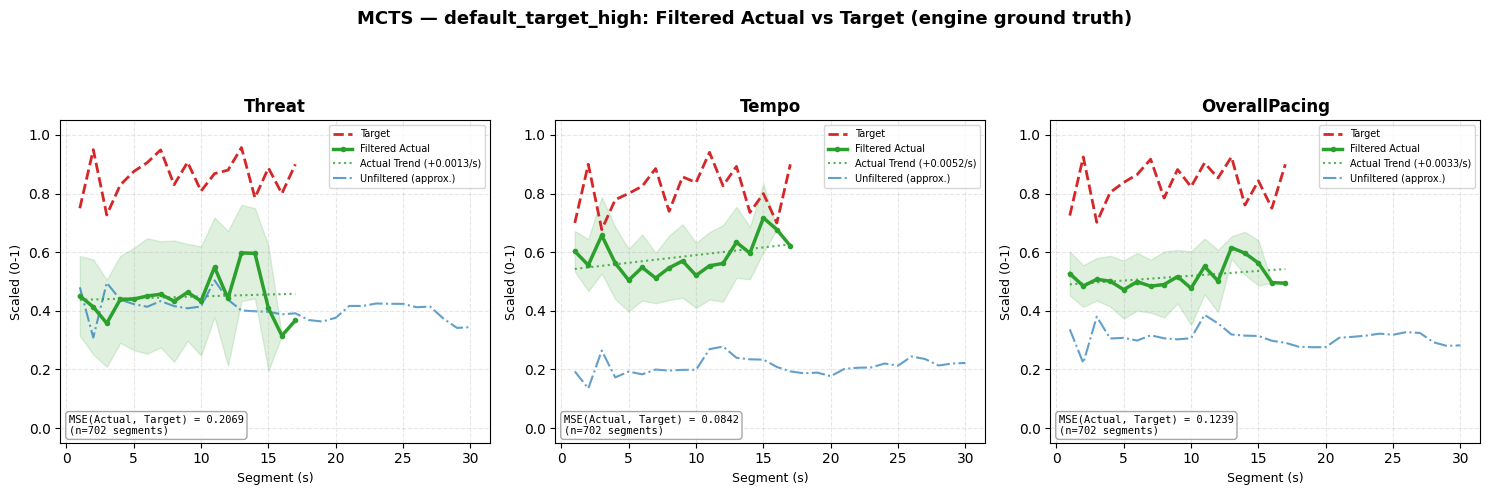

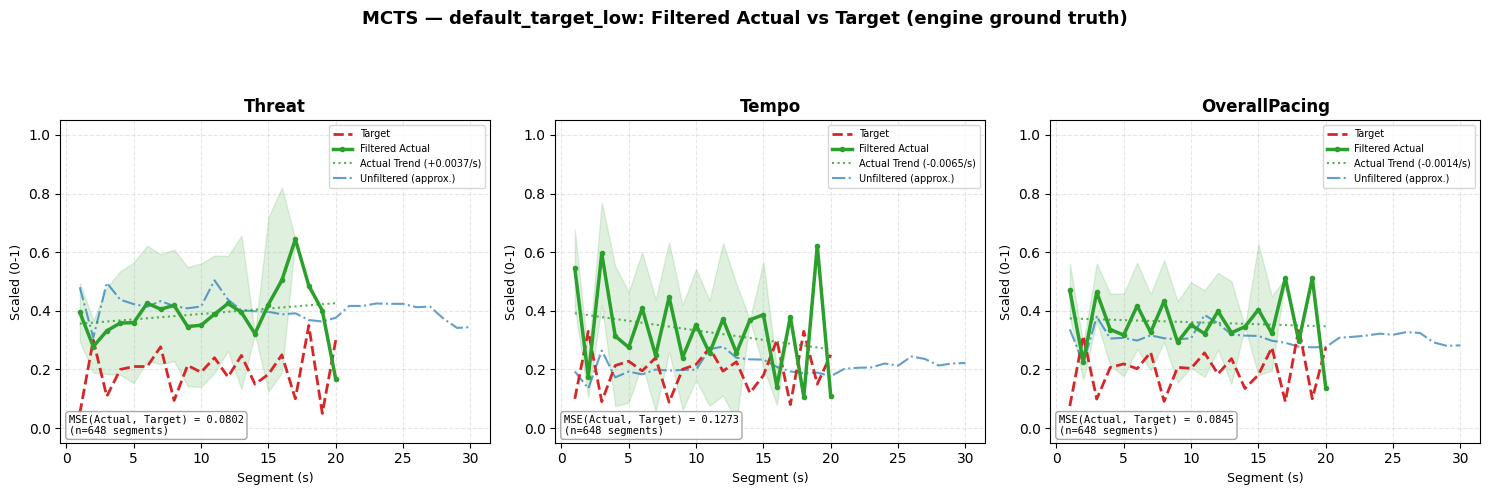

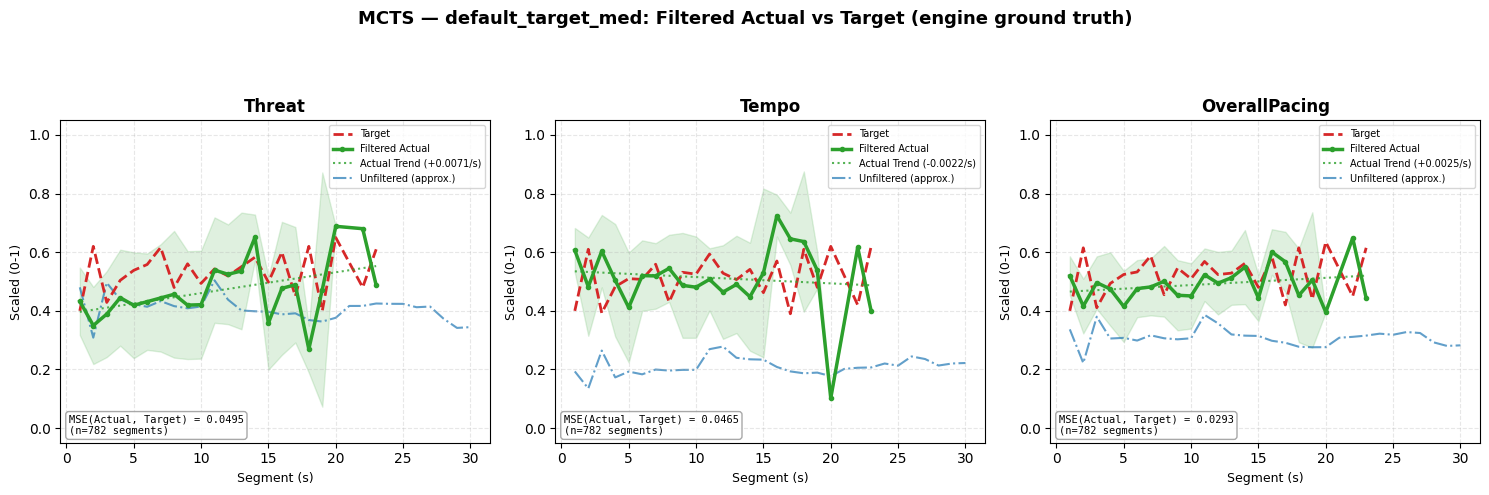

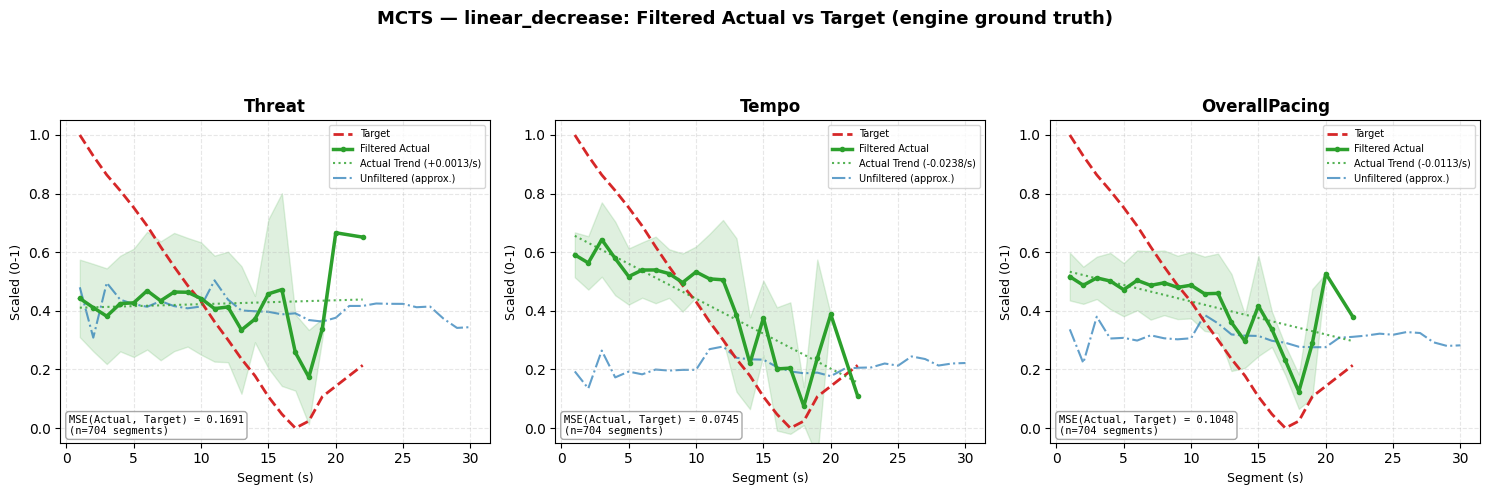

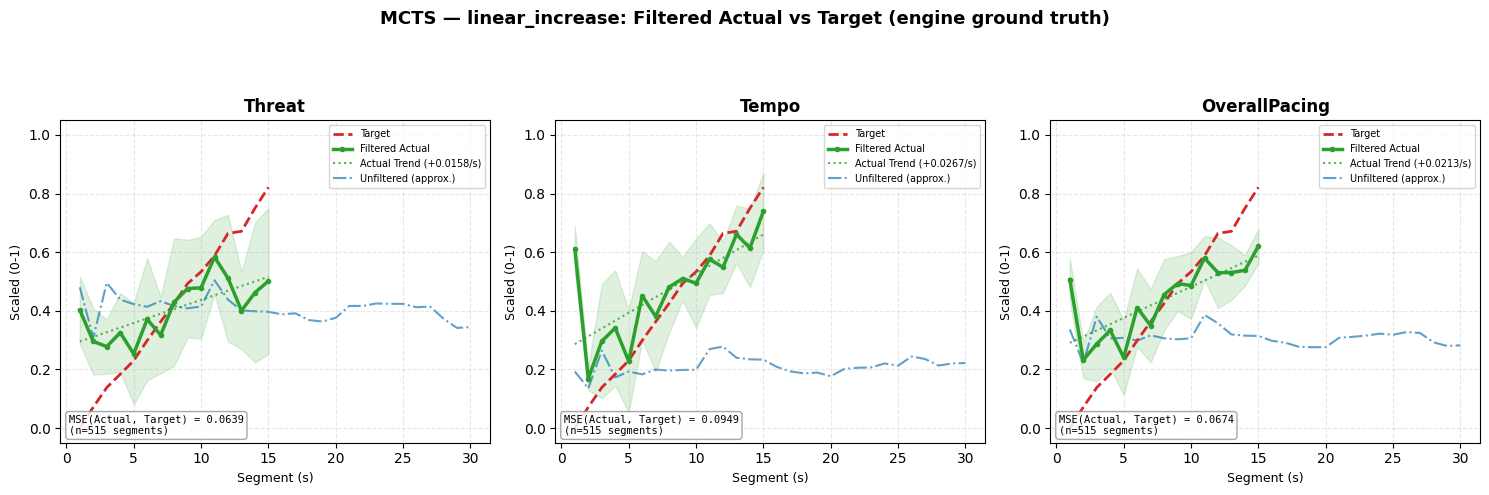

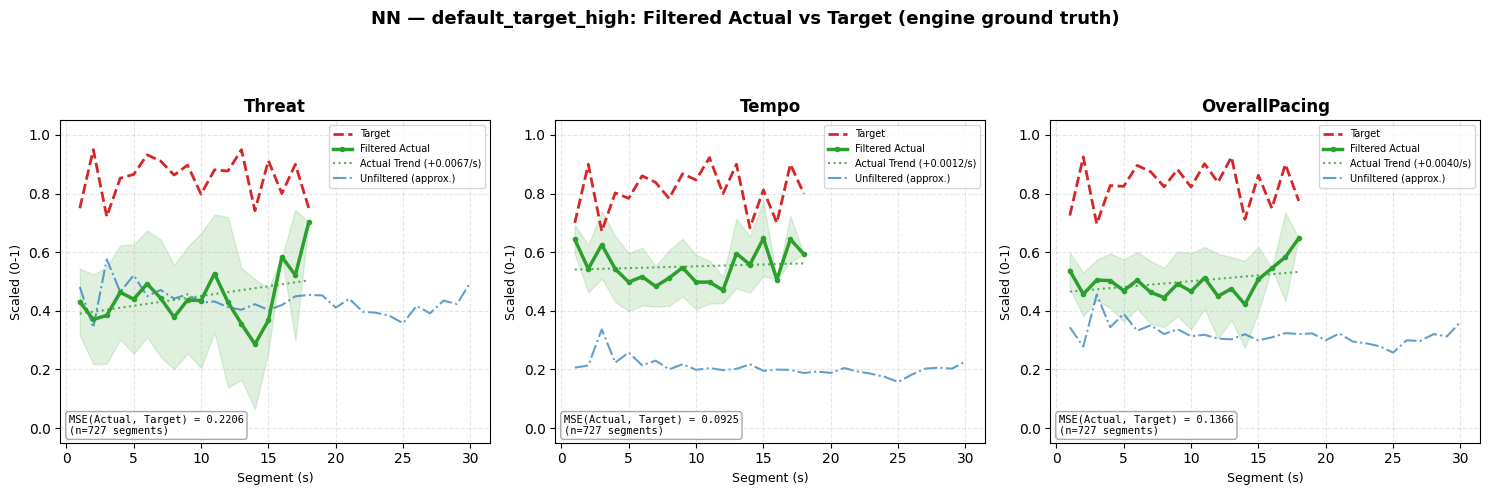

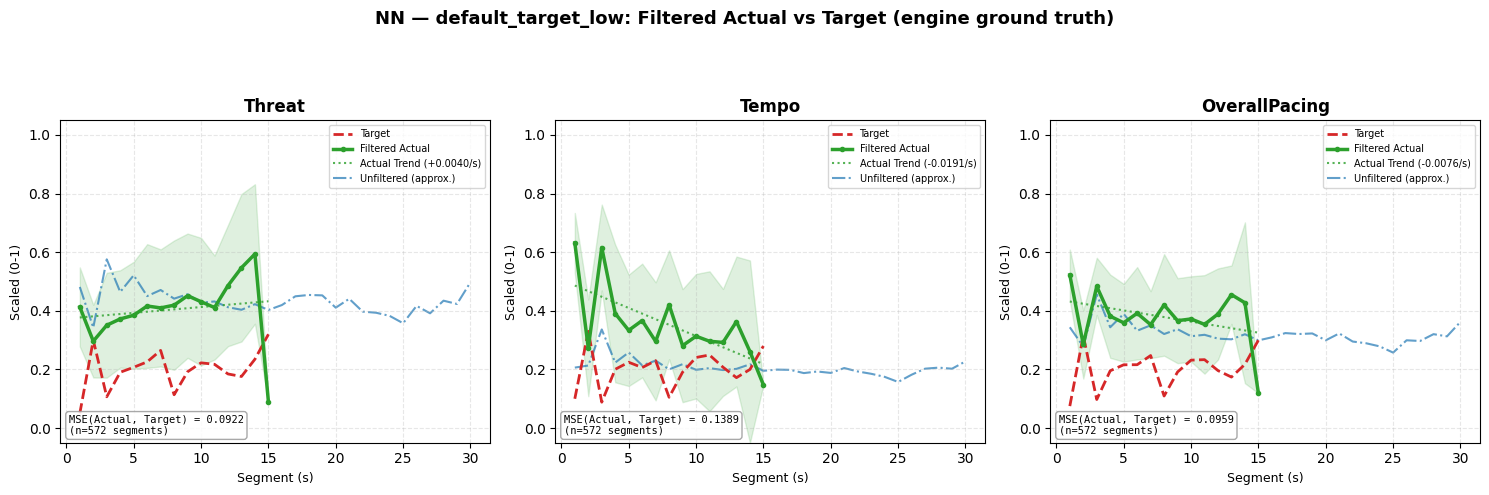

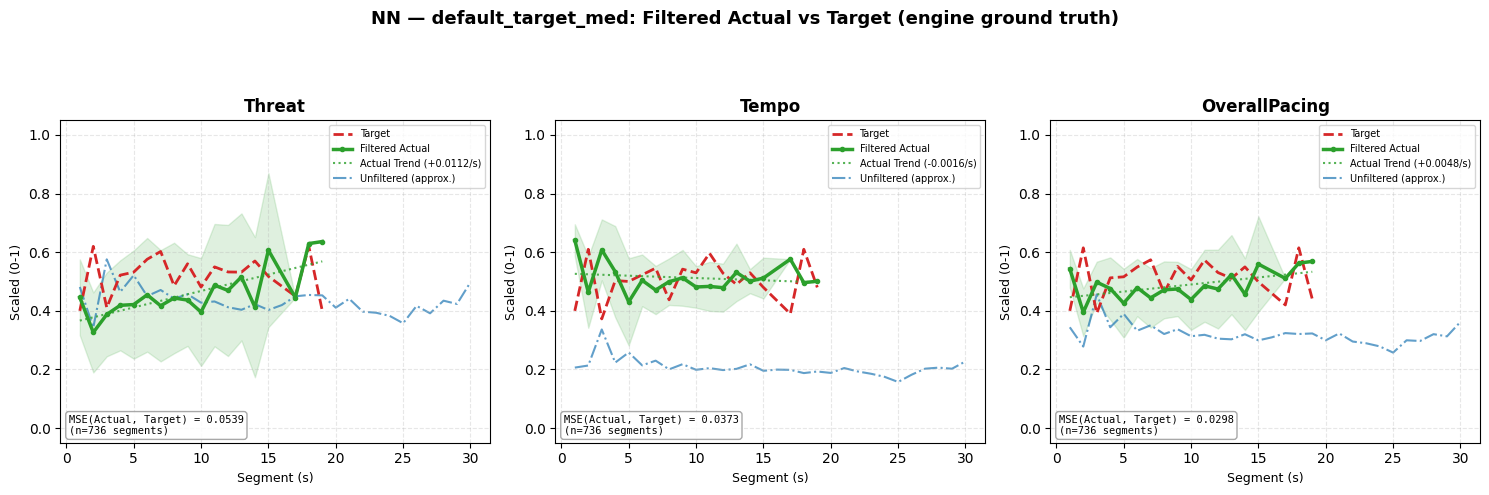

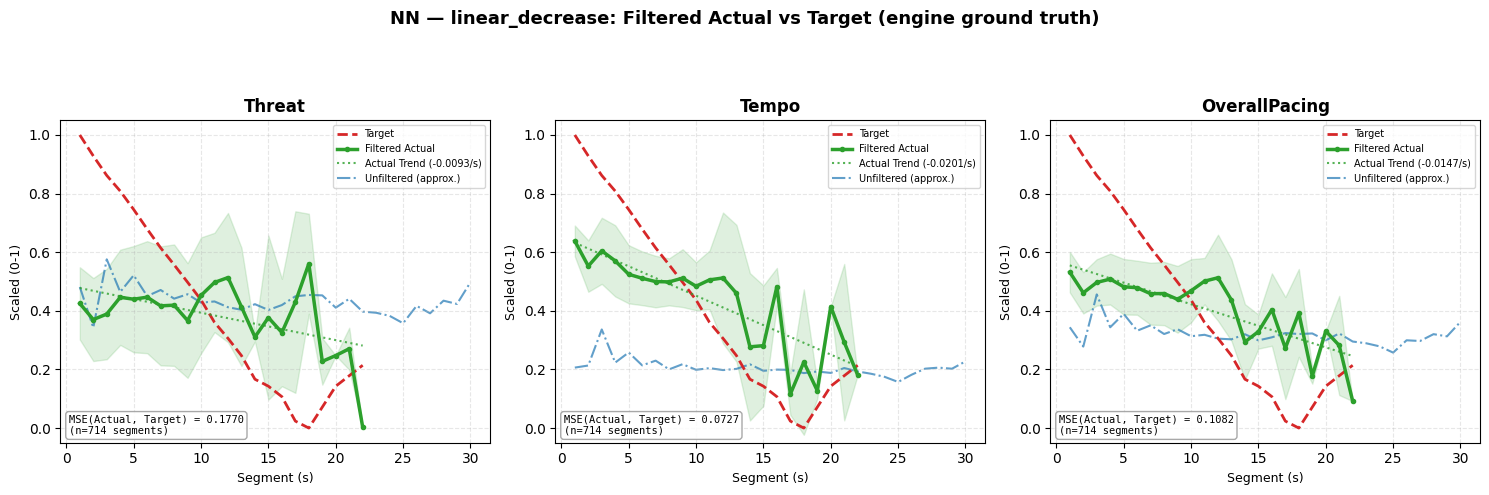

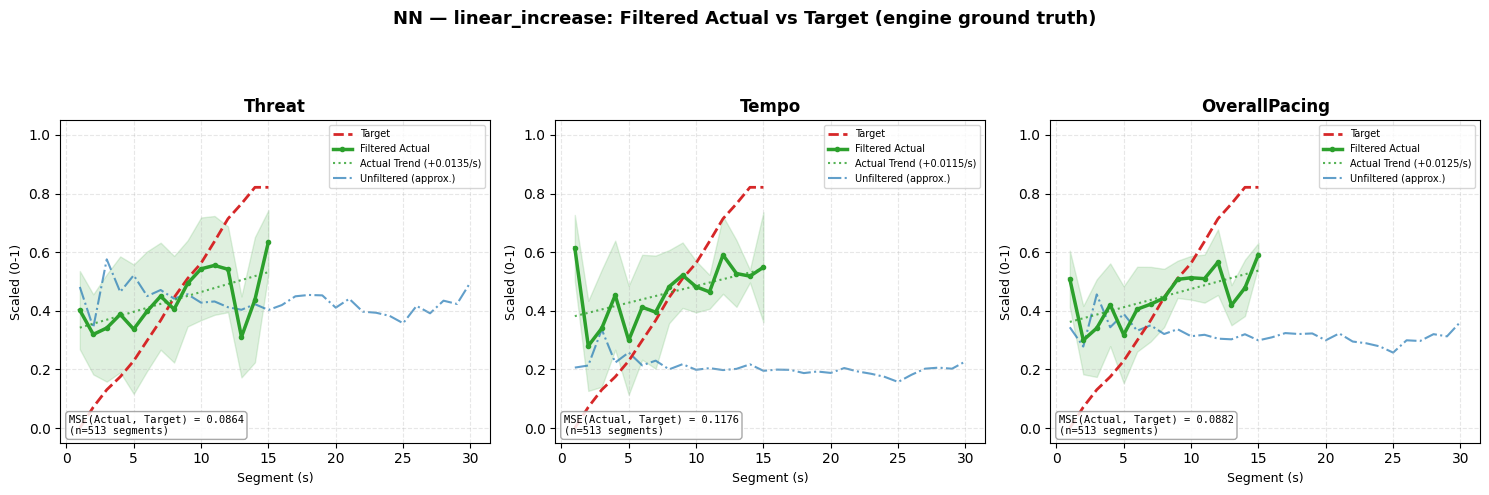

In [14]:
from plotting.pacing_filter_comparison import plot_all_filtered_target_tracking

figs_target_tracking = plot_all_filtered_target_tracking(
    df_pacing_factor_comparison, df_target_tracking, output_dir=comparison_output_dir,
)


### Merged (Both Applied Bots Pooled)

Same Actual-vs-Target tracking, but MCTS and NN pooled into one line per `PacingTarget` instead of a separate chart each — 5 figures total instead of 10. Mirrors how `plotting.pacing_target_analyzer.plot_pacing_target_tracking` already pools every "Applied"-role bot together by default.


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_default_target_high_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_default_target_low_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_default_target_med_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_linear_decrease_target_tracking.png


✅ Saved: .analytic-cache/result/filtered_vs_unfiltered/pacing_factor_charts/applied_linear_increase_target_tracking.png


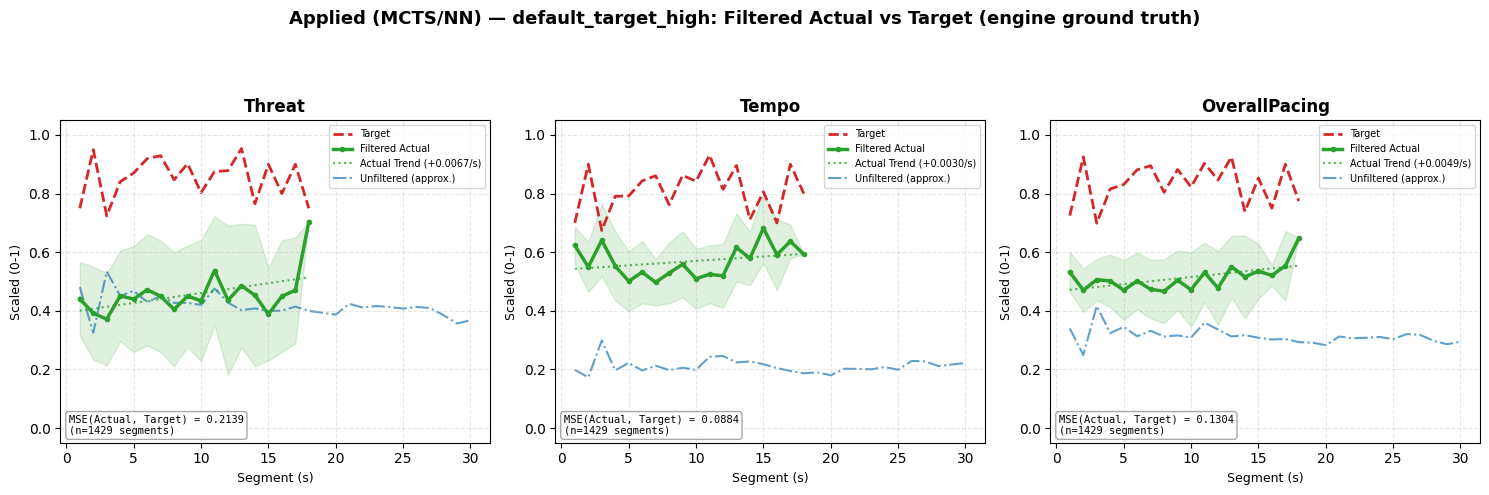

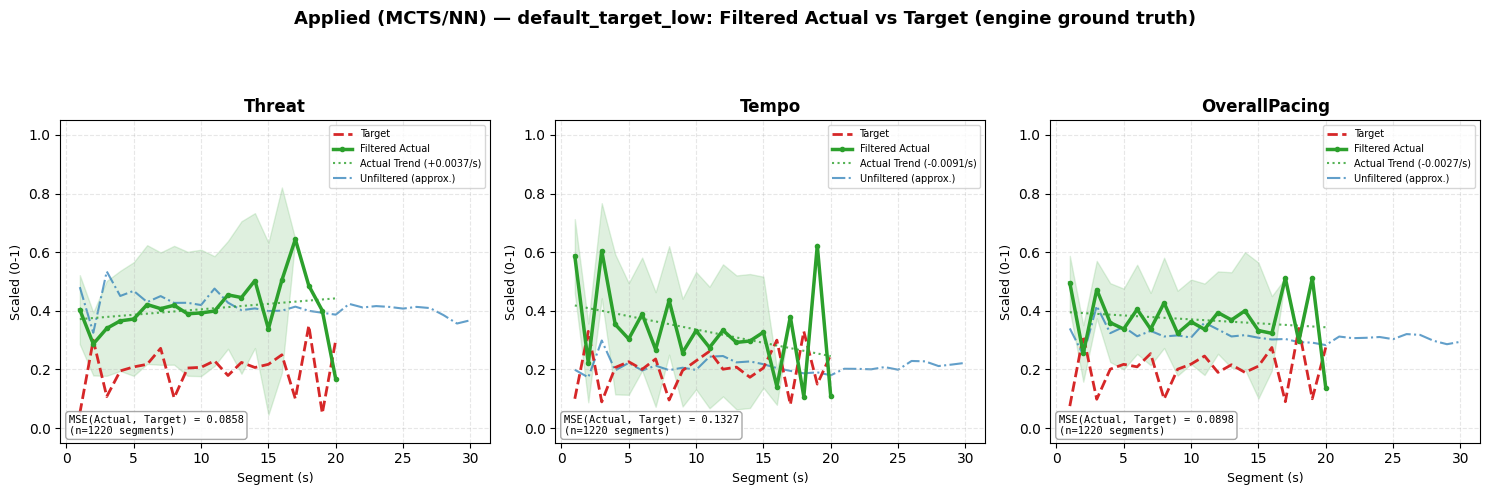

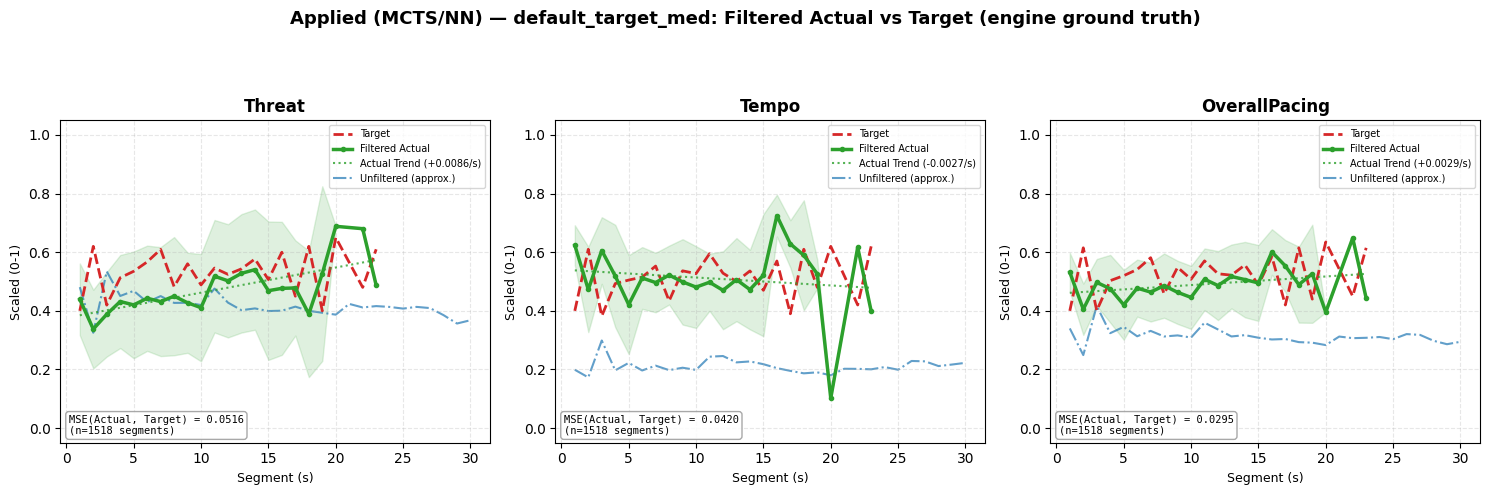

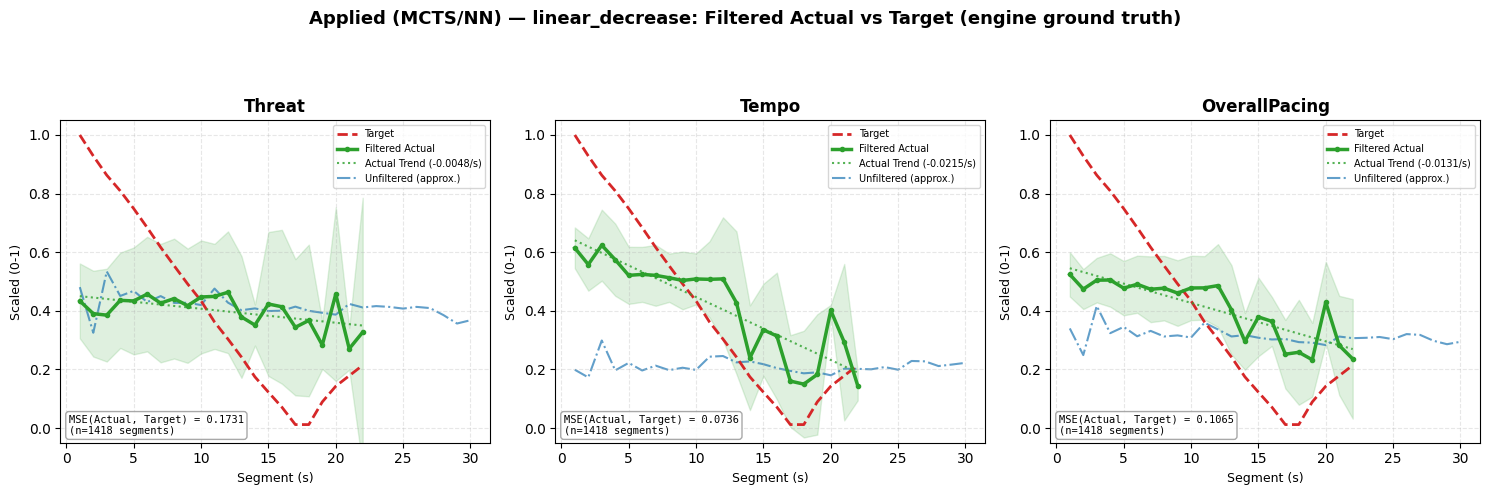

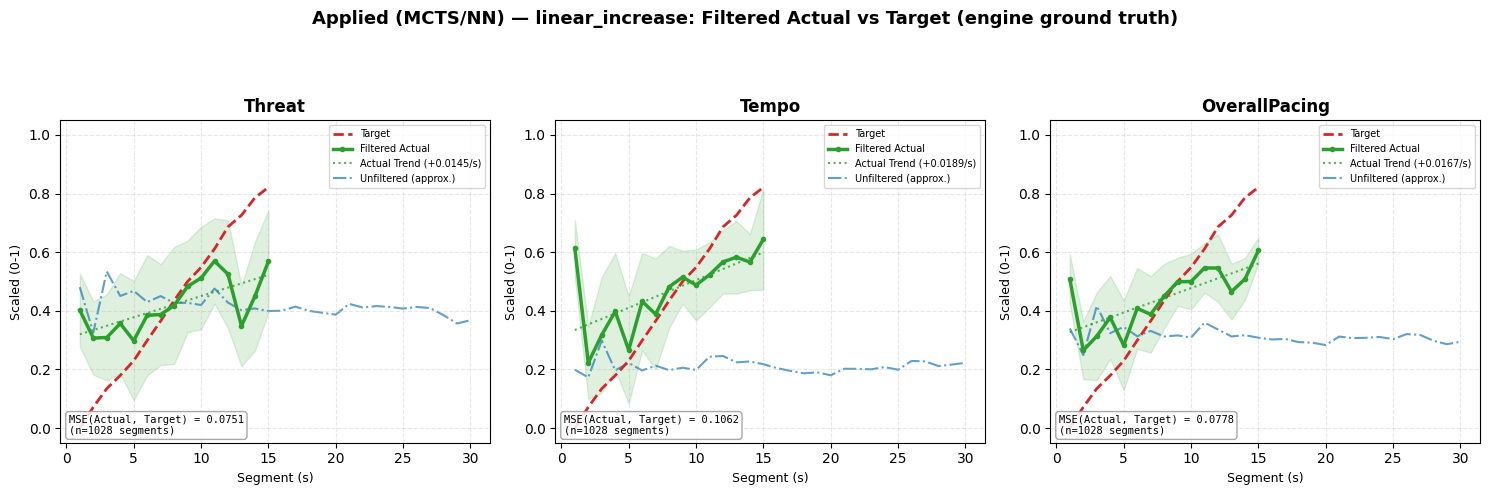

In [15]:
from plotting.pacing_filter_comparison import plot_all_filtered_target_tracking_merged

figs_target_tracking_merged = plot_all_filtered_target_tracking_merged(
    df_pacing_factor_comparison, df_target_tracking, output_dir=comparison_output_dir,
)
